In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

import torch
import torch.nn as nn

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from torchvision import models
from torchvision import transforms

from tqdm.auto import tqdm

In [2]:
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"

PROCESSED_DIR = DATA_DIR / "processed"

CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"

OUTPUT_DIR = PROJECT_ROOT / "outputs"

ERROR_ANALYSIS_DIR = OUTPUT_DIR / "error_analysis"

ERROR_ANALYSIS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CHECKPOINT_PATH = (
    CHECKPOINT_DIR
    / "resnet18_finetuned_best.pt"
)

TEST_CSV = (
    PROCESSED_DIR
    / "test_spatial.csv"
)

CLASS_NAMES = [

    "AnnualCrop",

    "Forest",

    "HerbaceousVegetation",

    "Highway",

    "Industrial",

    "Pasture",

    "PermanentCrop",

    "Residential",

    "River",

    "SeaLake"

]

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(f"Device: {DEVICE}")

Device: cuda


In [3]:
model = models.resnet18(
    weights=None
)

model.fc = nn.Linear(
    model.fc.in_features,
    len(CLASS_NAMES)
)

model.load_state_dict(
    torch.load(
        CHECKPOINT_PATH,
        map_location=DEVICE
    )
)

model.to(DEVICE)

model.eval()

print("Model loaded successfully.")

Model loaded successfully.


In [4]:
EUROSAT_MEAN = [
    0.34437724,
    0.38029198,
    0.40777111
]

EUROSAT_STD = [
    0.20265734,
    0.13689059,
    0.11554374
]

In [5]:
transform = transforms.Compose([

    transforms.Resize(
        (224, 224)
    ),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=EUROSAT_MEAN,
        
        std=EUROSAT_STD

    )

])


class EuroSATDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None
    ):

        self.dataframe = dataframe.reset_index(
            drop=True
        )

        self.transform = transform

        self.class_to_idx = {
            cls: idx
            for idx, cls in enumerate(CLASS_NAMES)
        }

    def __len__(self):

        return len(
            self.dataframe
        )

    def __getitem__(
        self,
        idx
    ):

        row = self.dataframe.iloc[idx]

        image = Image.open(
            row["filepath_rgb"]
        ).convert("RGB")

        if self.transform:

            image = self.transform(
                image
            )

        label = self.class_to_idx[
            row["class_name"]
        ]

        return (
            image,
            label,
            row["filepath_rgb"]
        )


test_df = pd.read_csv(
    TEST_CSV
)

test_dataset = EuroSATDataset(
    test_df,
    transform
)

test_loader = DataLoader(

    test_dataset,

    batch_size=64,

    shuffle=False,

    num_workers=0

)

print(test_df.shape)

test_df.head()

(2658, 8)


,filepath_rgb,filepath_tif,class_name,center_lat,center_lon,class_id,geo_cluster,split
0,c:\Users\ASUS\dev\projects\satellite-project-c...,c:\Users\ASUS\dev\projects\satellite-project-c...,AnnualCrop,39.085801,-1.829726,0,5,test
1,c:\Users\ASUS\dev\projects\satellite-project-c...,c:\Users\ASUS\dev\projects\satellite-project-c...,AnnualCrop,38.829654,-1.946284,0,5,test
2,c:\Users\ASUS\dev\projects\satellite-project-c...,c:\Users\ASUS\dev\projects\satellite-project-c...,AnnualCrop,37.382843,-5.574282,0,5,test
3,c:\Users\ASUS\dev\projects\satellite-project-c...,c:\Users\ASUS\dev\projects\satellite-project-c...,AnnualCrop,38.875303,-1.952169,0,5,test
4,c:\Users\ASUS\dev\projects\satellite-project-c...,c:\Users\ASUS\dev\projects\satellite-project-c...,AnnualCrop,37.349284,-5.621126,0,5,test


In [6]:
all_filepaths = []

all_true = []
all_pred = []

all_confidence = []

model.eval()

with torch.no_grad():

    for images, labels, filepaths in tqdm(test_loader):

        images = images.to(DEVICE)

        outputs = model(images)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        confidence, predictions = torch.max(
            probabilities,
            dim=1
        )

        all_filepaths.extend(filepaths)

        all_true.extend(
            labels.numpy()
        )

        all_pred.extend(
            predictions.cpu().numpy()
        )

        all_confidence.extend(
            confidence.cpu().numpy()
        )

print("Inference complete.")

  0%|          | 0/42 [00:00<?, ?it/s]

Inference complete.


In [7]:
results_df = pd.DataFrame({

    "filepath": all_filepaths,

    "true_label": all_true,

    "predicted_label": all_pred,

    "true_class": [
        CLASS_NAMES[i]
        for i in all_true
    ],

    "predicted_class": [
        CLASS_NAMES[i]
        for i in all_pred
    ],

    "confidence": all_confidence

})

results_df["correct"] = (

    results_df["true_label"]

    ==

    results_df["predicted_label"]

)

results_df.head()

,filepath,true_label,predicted_label,true_class,predicted_class,confidence,correct
0,c:\Users\ASUS\dev\projects\satellite-project-c...,0,0,AnnualCrop,AnnualCrop,0.987840,True
1,c:\Users\ASUS\dev\projects\satellite-project-c...,0,0,AnnualCrop,AnnualCrop,0.952006,True
2,c:\Users\ASUS\dev\projects\satellite-project-c...,0,0,AnnualCrop,AnnualCrop,0.999820,True
3,c:\Users\ASUS\dev\projects\satellite-project-c...,0,0,AnnualCrop,AnnualCrop,0.998892,True
4,c:\Users\ASUS\dev\projects\satellite-project-c...,0,0,AnnualCrop,AnnualCrop,0.999997,True


In [8]:
results_path = (
    ERROR_ANALYSIS_DIR
    / "prediction_results.csv"
)

results_df.to_csv(
    results_path,
    index=False
)

print(results_path)

c:\Users\ASUS\dev\projects\satellite-project-copy\outputs\error_analysis\prediction_results.csv


In [9]:
correct_conf = results_df[
    results_df["correct"]
]["confidence"]

incorrect_conf = results_df[
    ~results_df["correct"]
]["confidence"]

confidence_stats = pd.DataFrame({

    "Correct": correct_conf.describe(),

    "Incorrect": incorrect_conf.describe()

})

confidence_stats

,Correct,Incorrect
count,2270.000000,388.000000
mean,0.963418,0.830449
std,0.092073,0.168750
min,0.417423,0.363260
25%,0.986509,0.710548
50%,0.999421,0.884855
75%,0.999985,0.980338
max,1.000000,1.000000


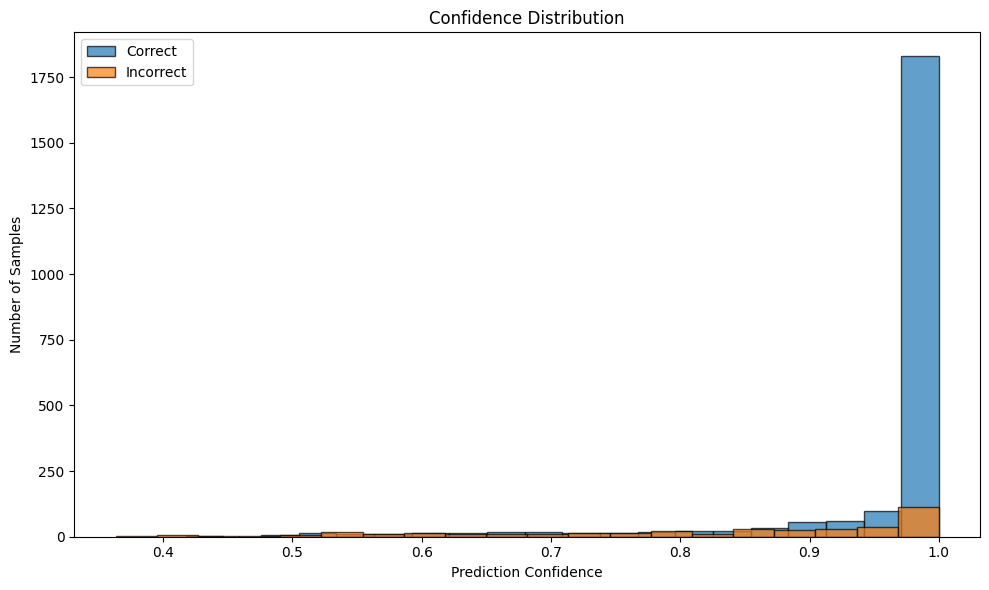

In [10]:
plt.figure(figsize=(10, 6))

plt.hist(
    correct_conf,
    bins=20,
    alpha=0.7,
    label="Correct",
    edgecolor="black"
)

plt.hist(
    incorrect_conf,
    bins=20,
    alpha=0.7,
    label="Incorrect",
    edgecolor="black"
)

plt.xlabel("Prediction Confidence")
plt.ylabel("Number of Samples")
plt.title("Confidence Distribution")

plt.legend()

plt.tight_layout()

plt.savefig(
    ERROR_ANALYSIS_DIR / "confidence_histogram.png",
    dpi=300
)

plt.show()

In [11]:
summary = pd.DataFrame({

    "Group": [
        "Correct",
        "Incorrect"
    ],

    "Mean Confidence": [

        correct_conf.mean(),

        incorrect_conf.mean()

    ],

    "Median Confidence": [

        correct_conf.median(),

        incorrect_conf.median()

    ]

})

summary

,Group,Mean Confidence,Median Confidence
0,Correct,0.963418,0.999421
1,Incorrect,0.830449,0.884855


## Confidence Analysis

Questions to answer:

- Are incorrect predictions generally lower confidence than correct predictions?
- Are there any highly confident incorrect predictions?
- Does prediction confidence appear to correlate with correctness?

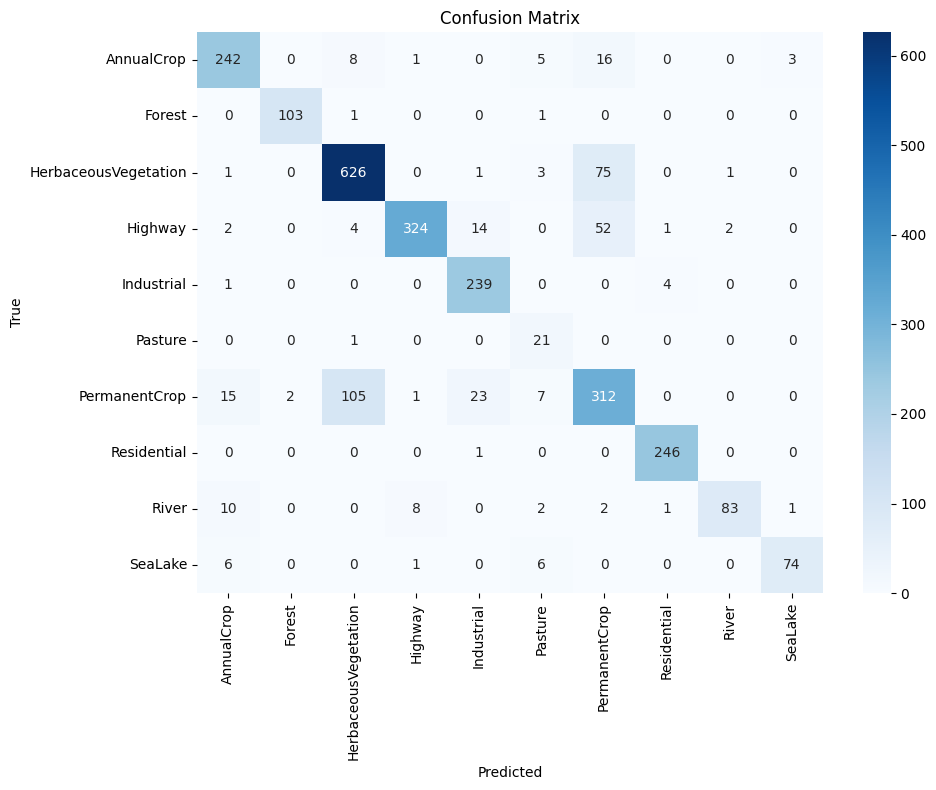

In [12]:
cm = confusion_matrix(
    results_df["true_label"],
    results_df["predicted_label"]
)

plt.figure(figsize=(10, 8))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=CLASS_NAMES,

    yticklabels=CLASS_NAMES

)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.tight_layout()

plt.savefig(
    ERROR_ANALYSIS_DIR / "confusion_matrix.png",
    dpi=300
)

plt.show()

In [13]:
confusions = []

for true in range(len(CLASS_NAMES)):

    for pred in range(len(CLASS_NAMES)):

        if true == pred:
            continue

        count = cm[true, pred]

        if count > 0:

            confusions.append({

                "True Class": CLASS_NAMES[true],

                "Predicted Class": CLASS_NAMES[pred],

                "Count": count

            })

confusion_df = pd.DataFrame(confusions)

confusion_df = confusion_df.sort_values(
    "Count",
    ascending=False
)

confusion_df.head(20)

,True Class,Predicted Class,Count
23,PermanentCrop,HerbaceousVegetation,105
10,HerbaceousVegetation,PermanentCrop,75
15,Highway,PermanentCrop,52
25,PermanentCrop,Industrial,23
3,AnnualCrop,PermanentCrop,16
21,PermanentCrop,AnnualCrop,15
14,Highway,Industrial,14
28,River,AnnualCrop,10
0,AnnualCrop,HerbaceousVegetation,8
29,River,Highway,8


In [14]:
confusion_df.to_csv(

    ERROR_ANALYSIS_DIR / "confusion_pairs.csv",

    index=False

)

confusion_df.head(10)

,True Class,Predicted Class,Count
23,PermanentCrop,HerbaceousVegetation,105
10,HerbaceousVegetation,PermanentCrop,75
15,Highway,PermanentCrop,52
25,PermanentCrop,Industrial,23
3,AnnualCrop,PermanentCrop,16
21,PermanentCrop,AnnualCrop,15
14,Highway,Industrial,14
28,River,AnnualCrop,10
0,AnnualCrop,HerbaceousVegetation,8
29,River,Highway,8


## Confusion Analysis

Questions to answer:

- Which class pairs are confused most frequently?
- Are these classes visually similar?
- Are most mistakes between vegetation classes, urban classes, or water classes?
- Do the observed confusions agree with the class-wise F1 scores?

Class: AnnualCrop


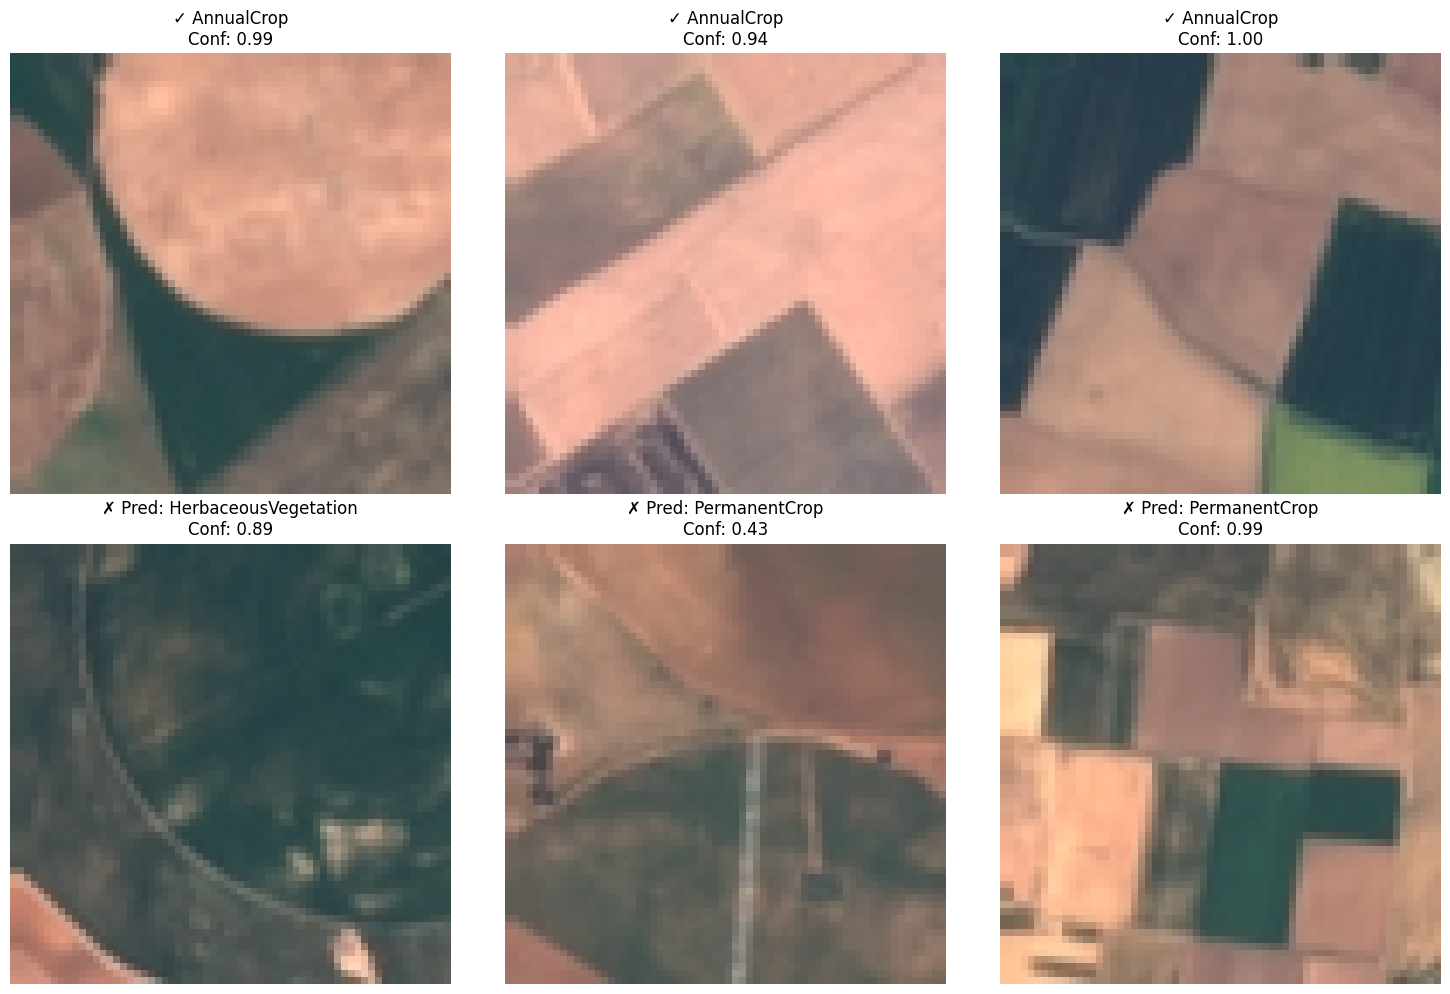

Class: Forest


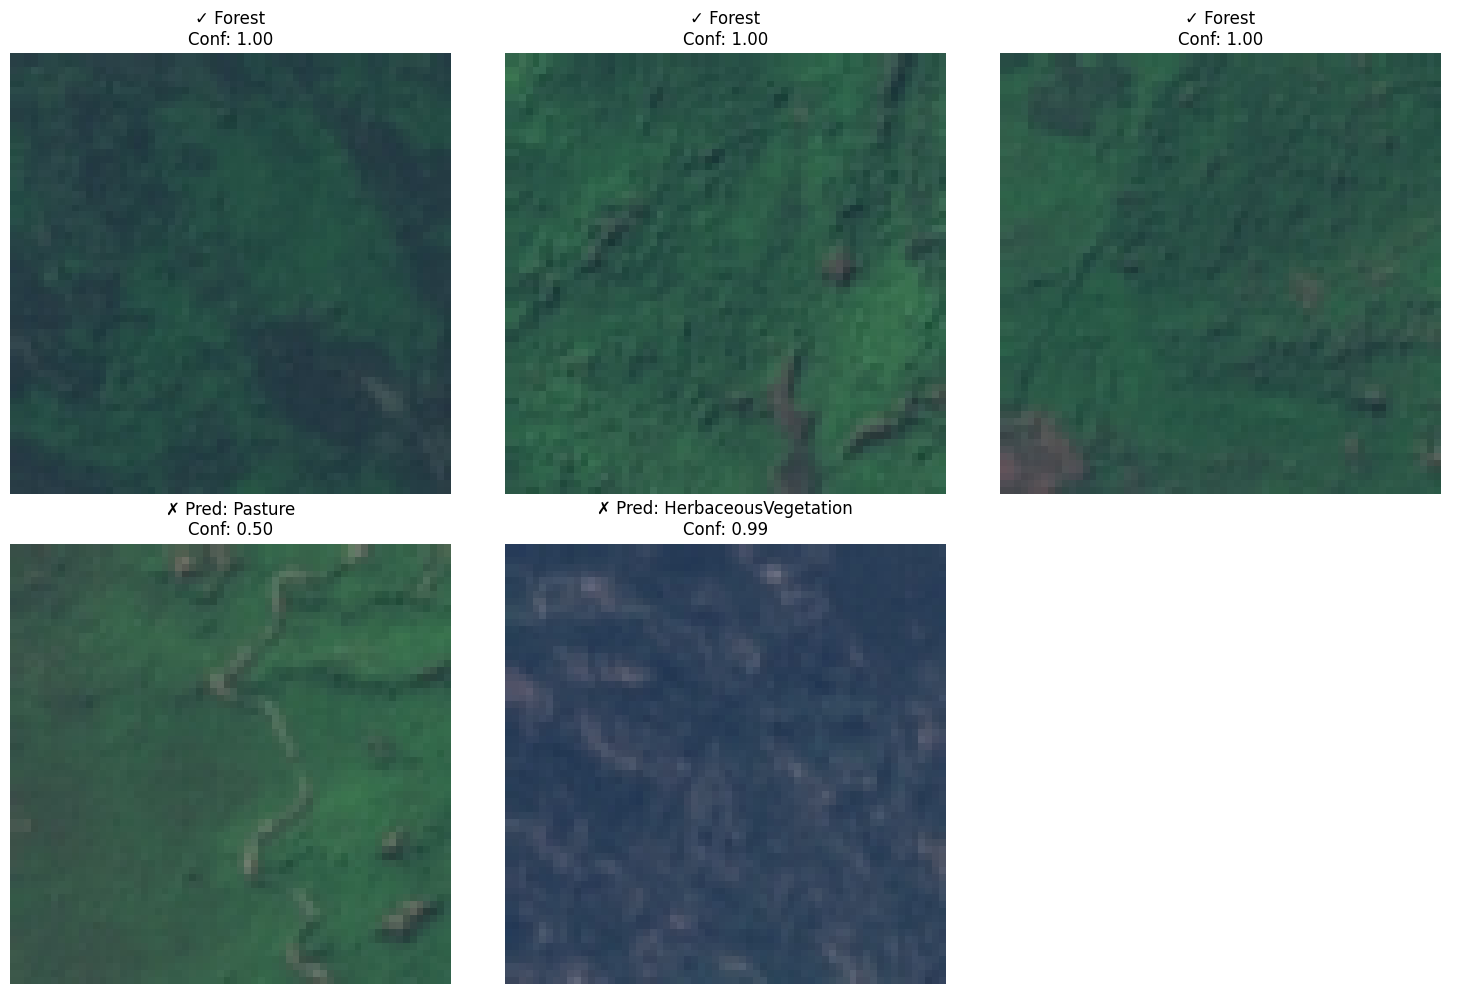

Class: HerbaceousVegetation


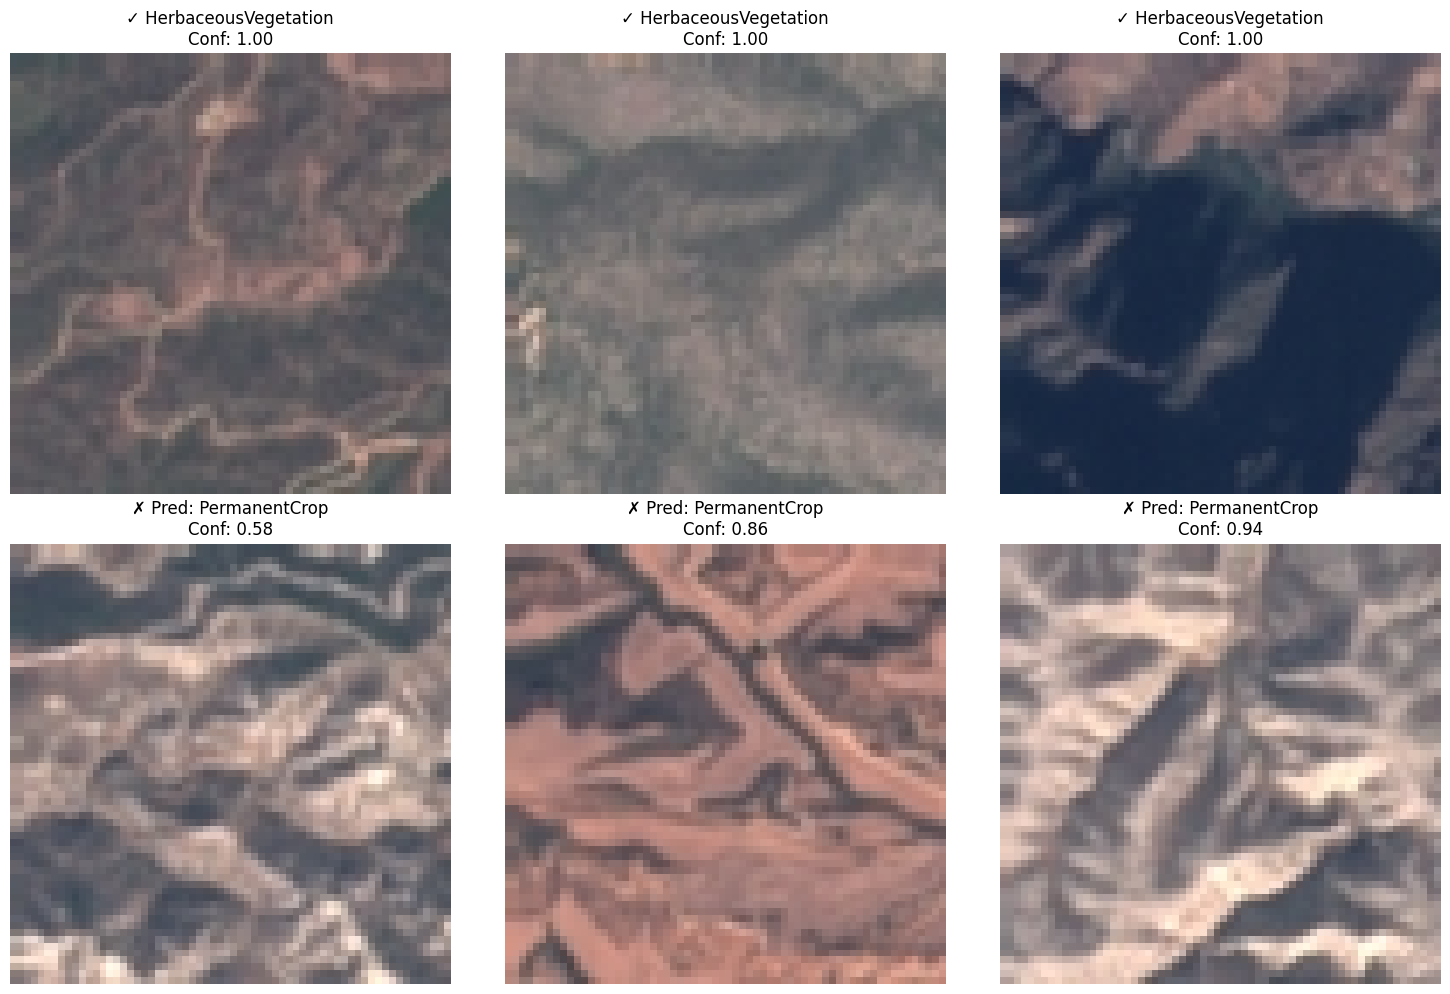

Class: Highway


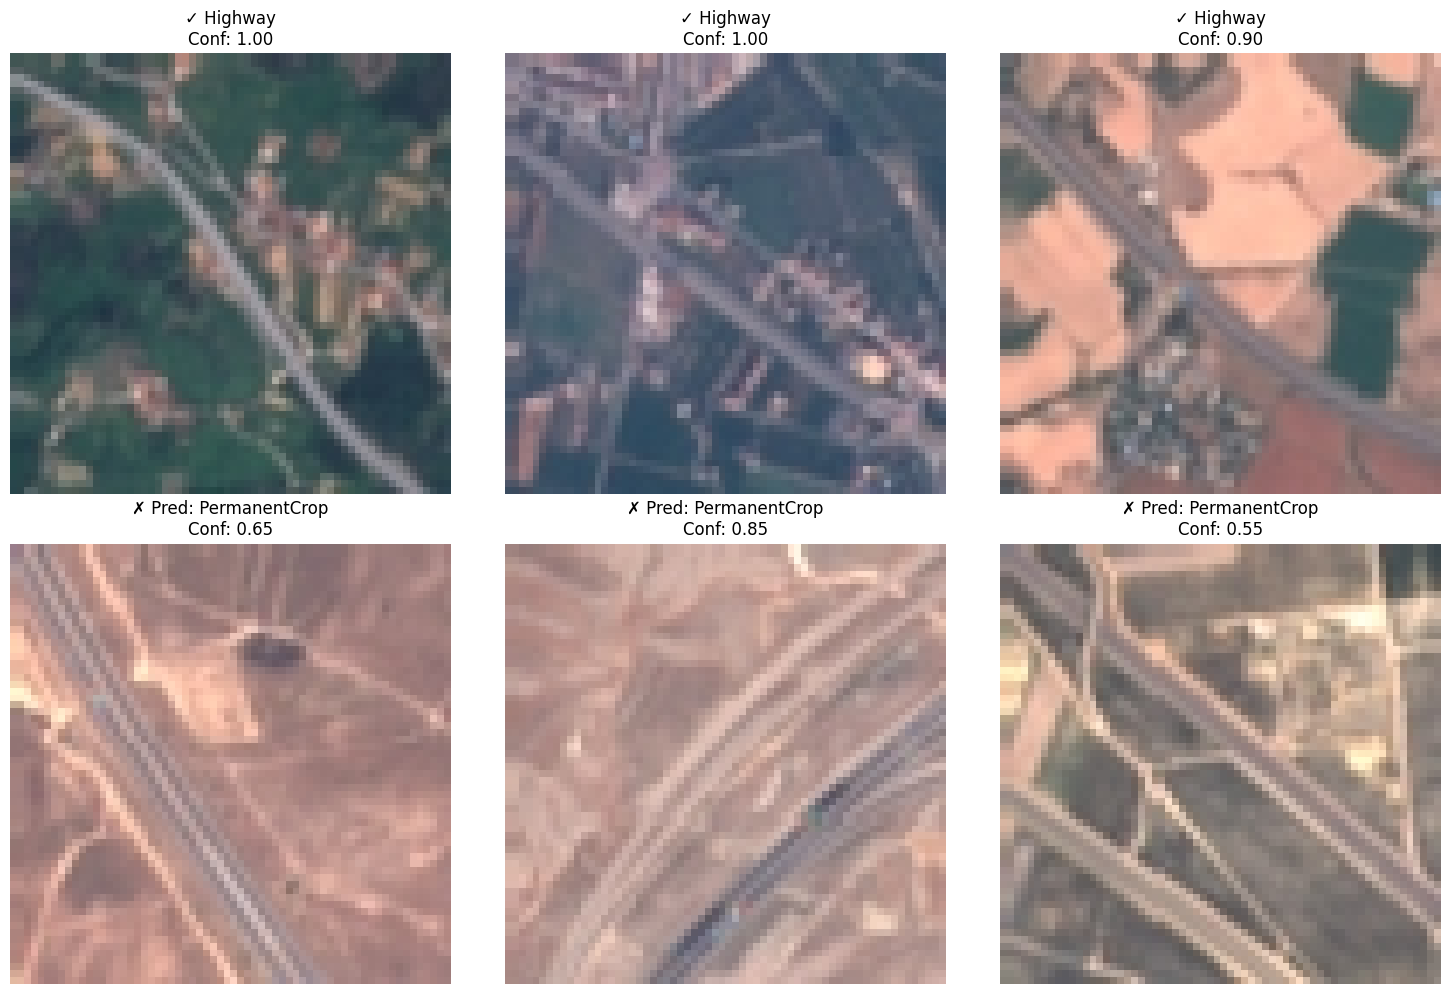

Class: Industrial


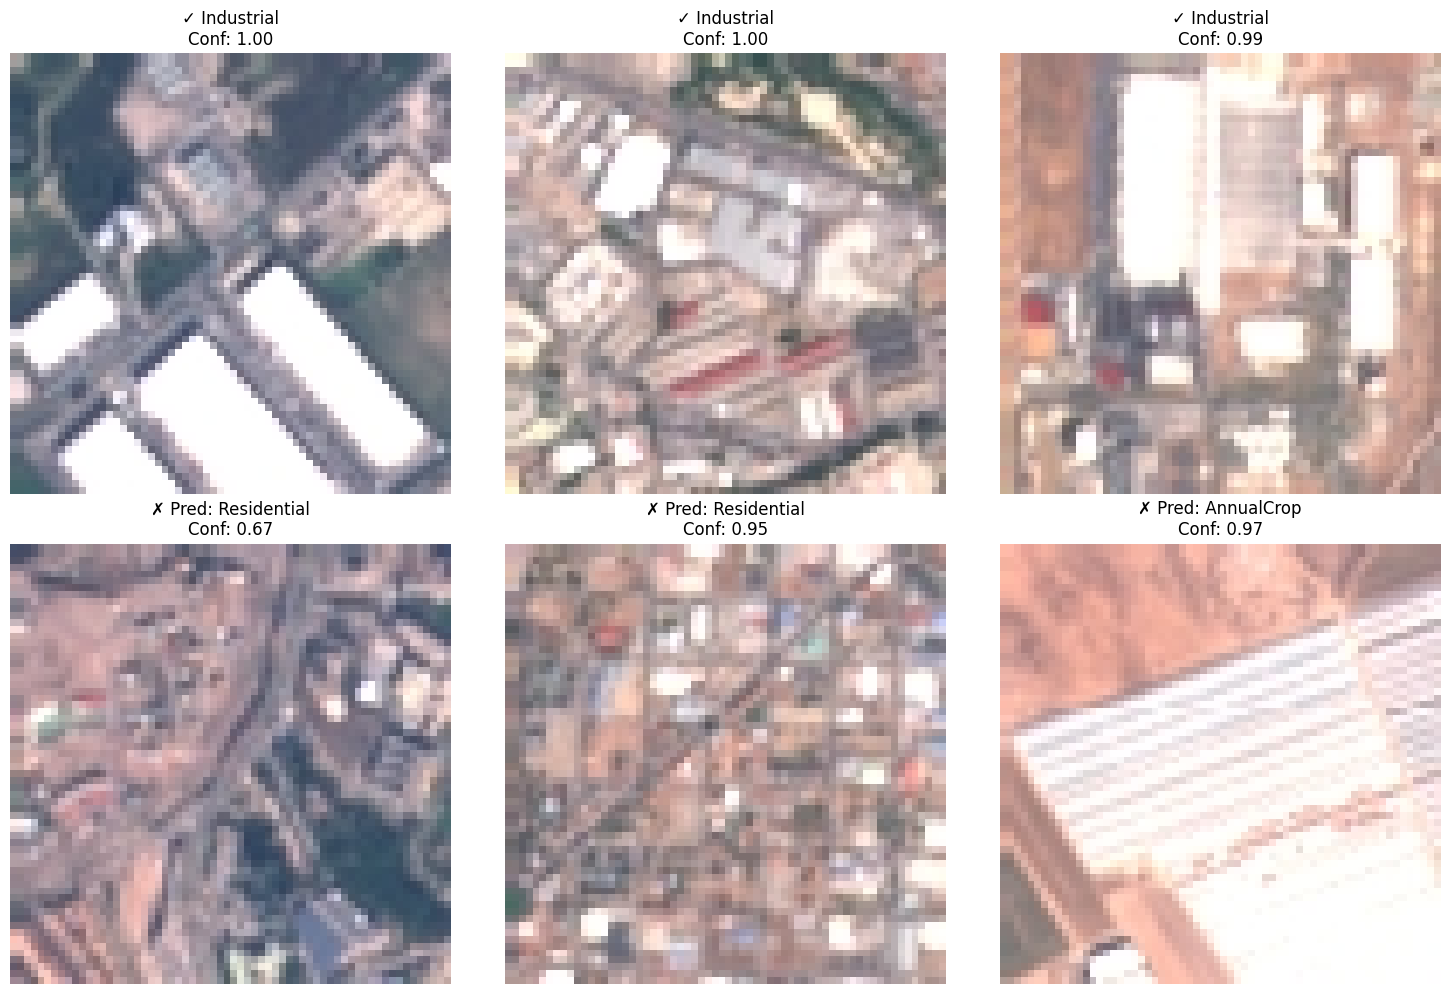

Class: Pasture


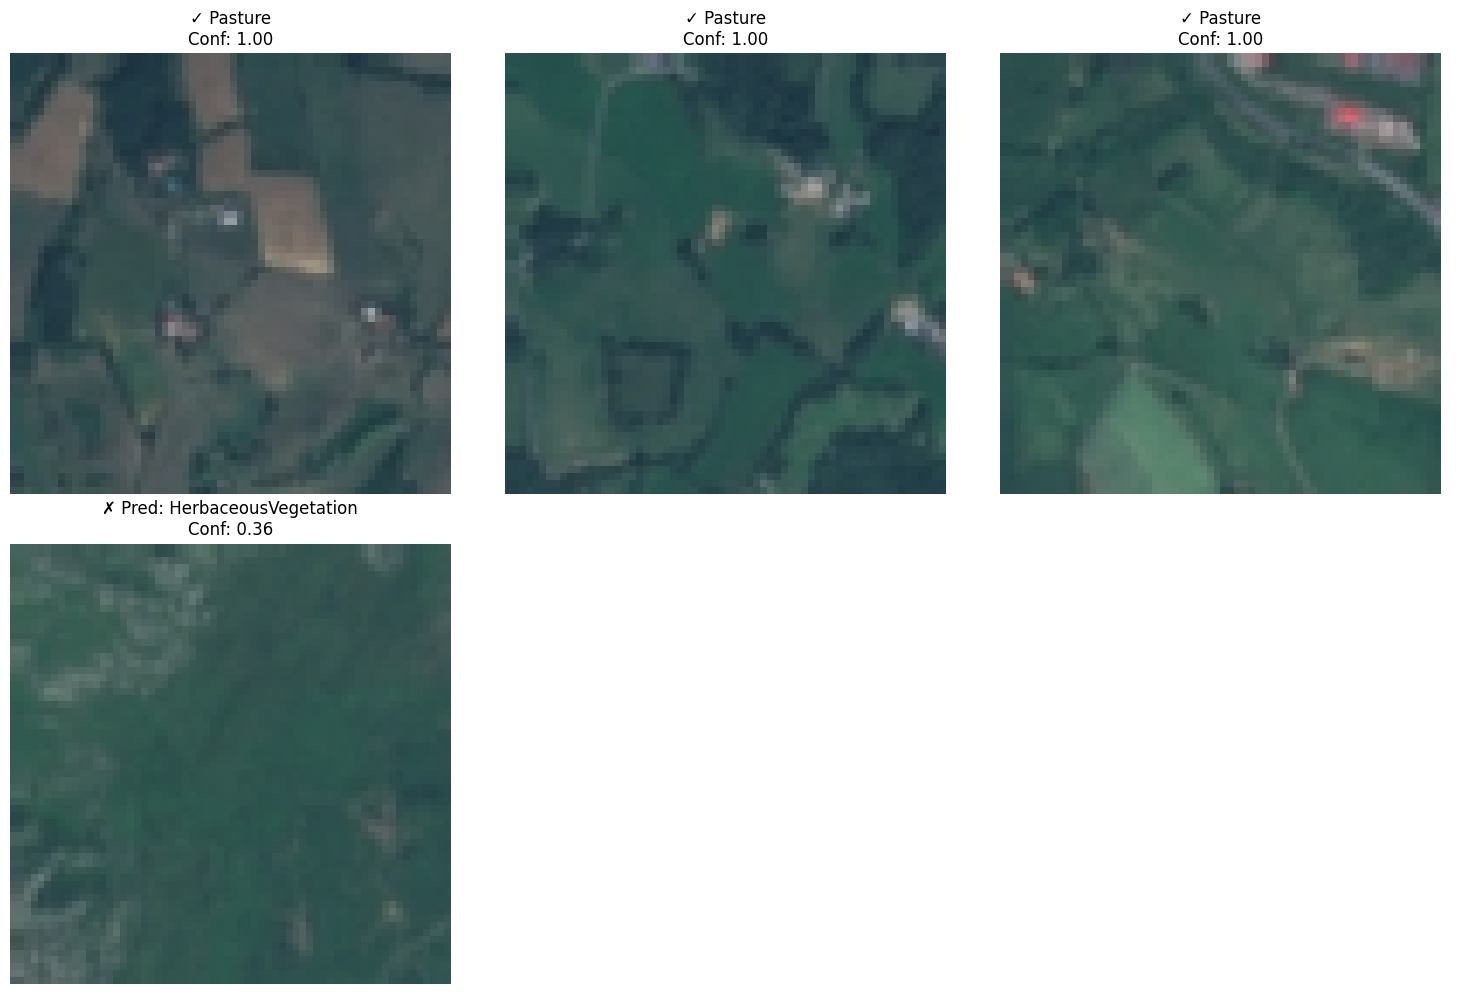

Class: PermanentCrop


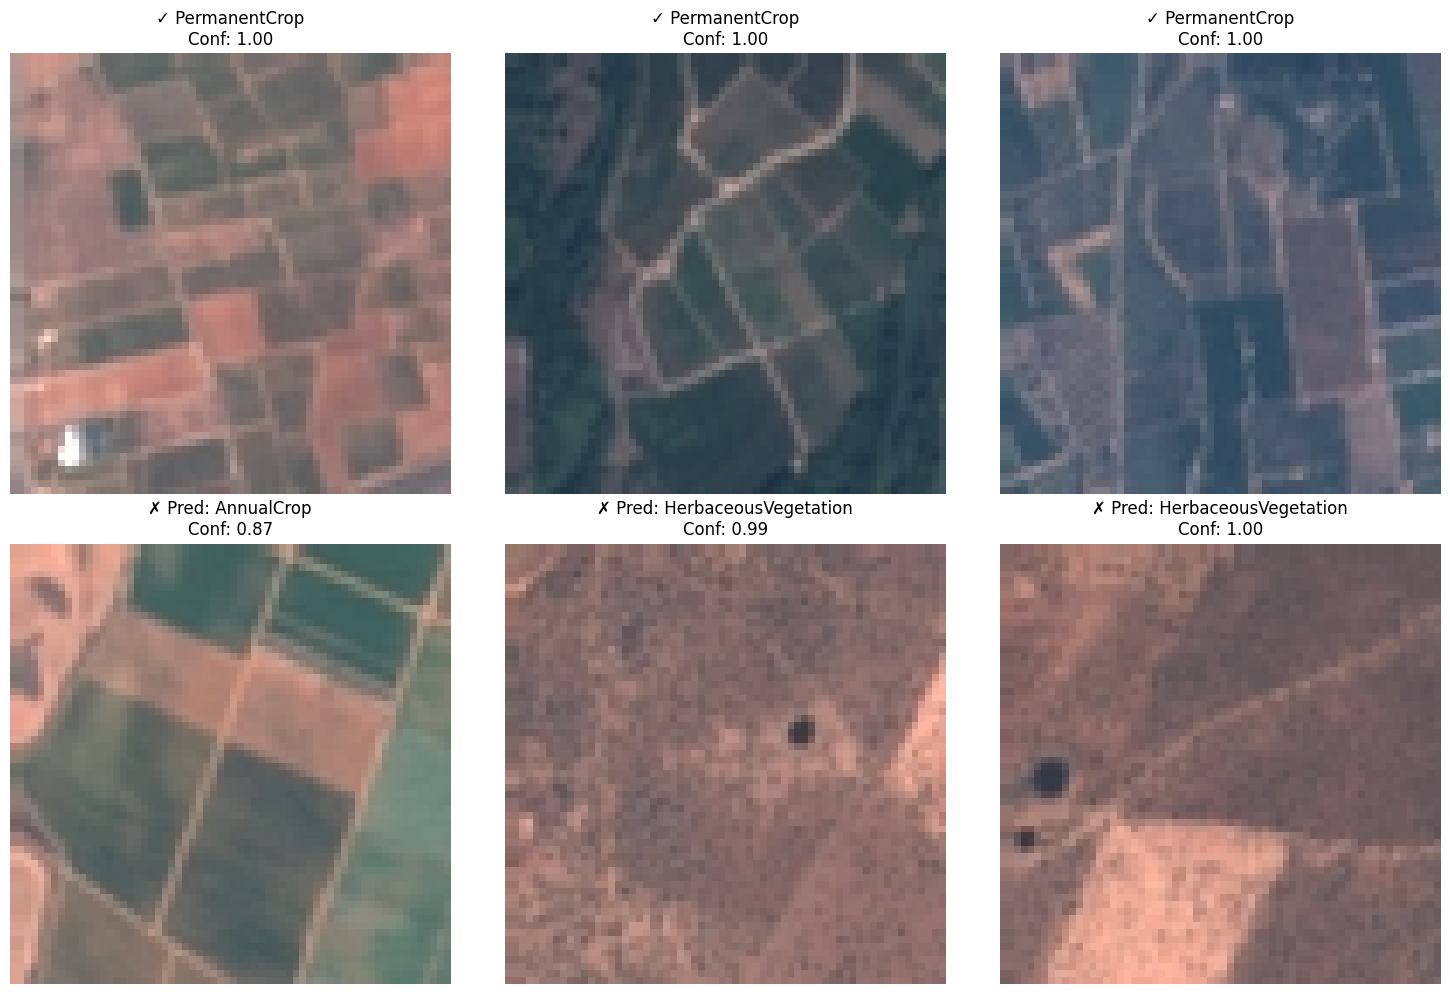

Class: Residential


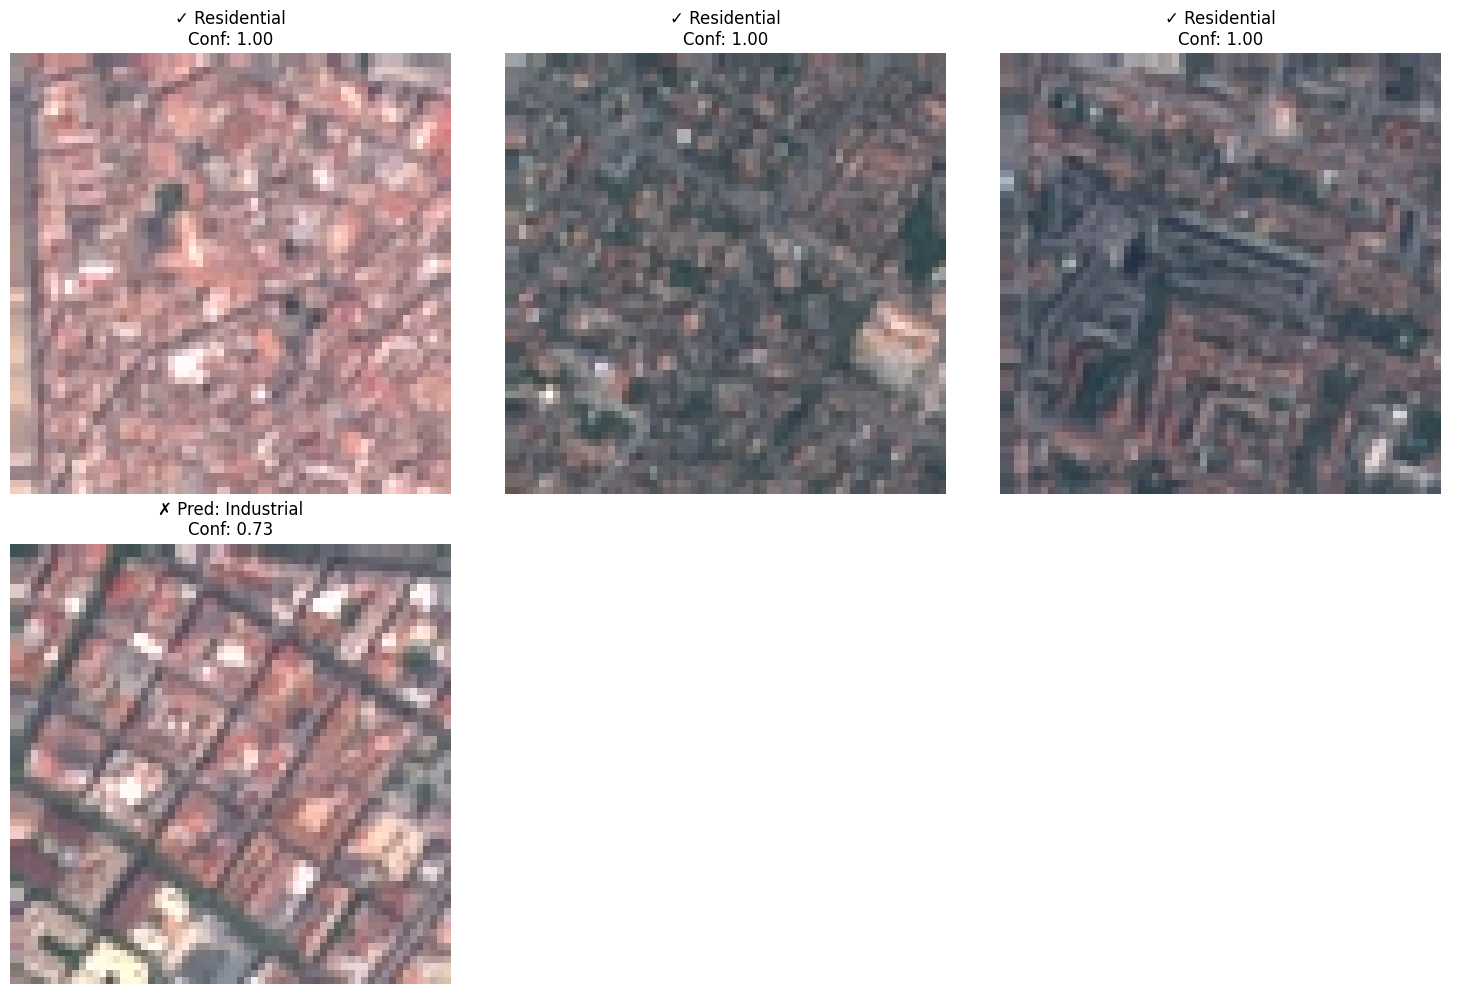

Class: River


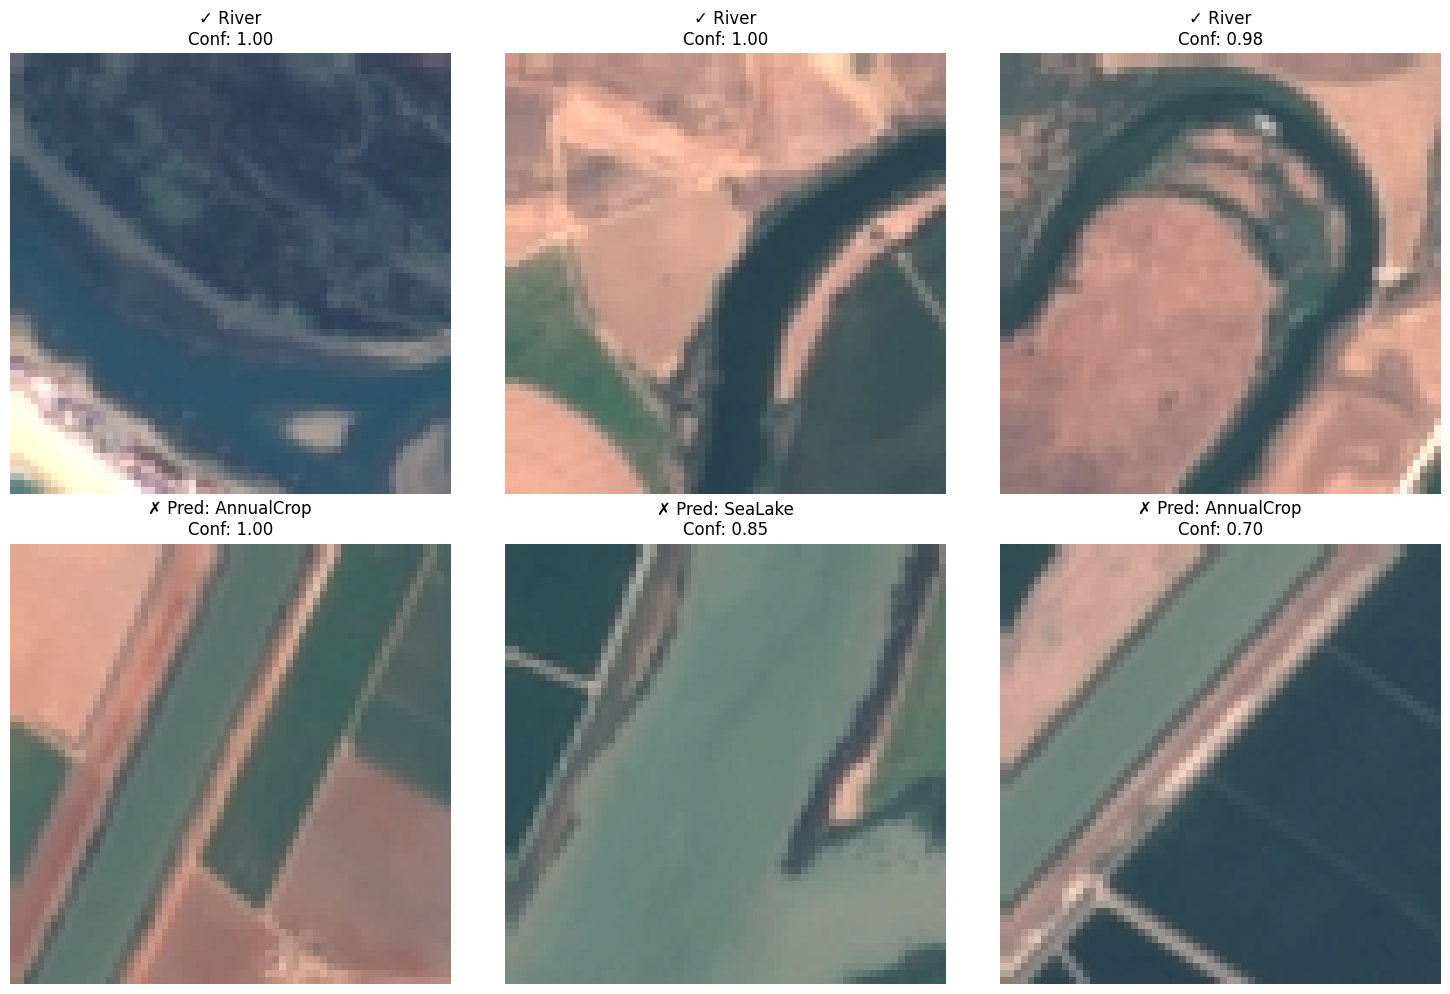

Class: SeaLake


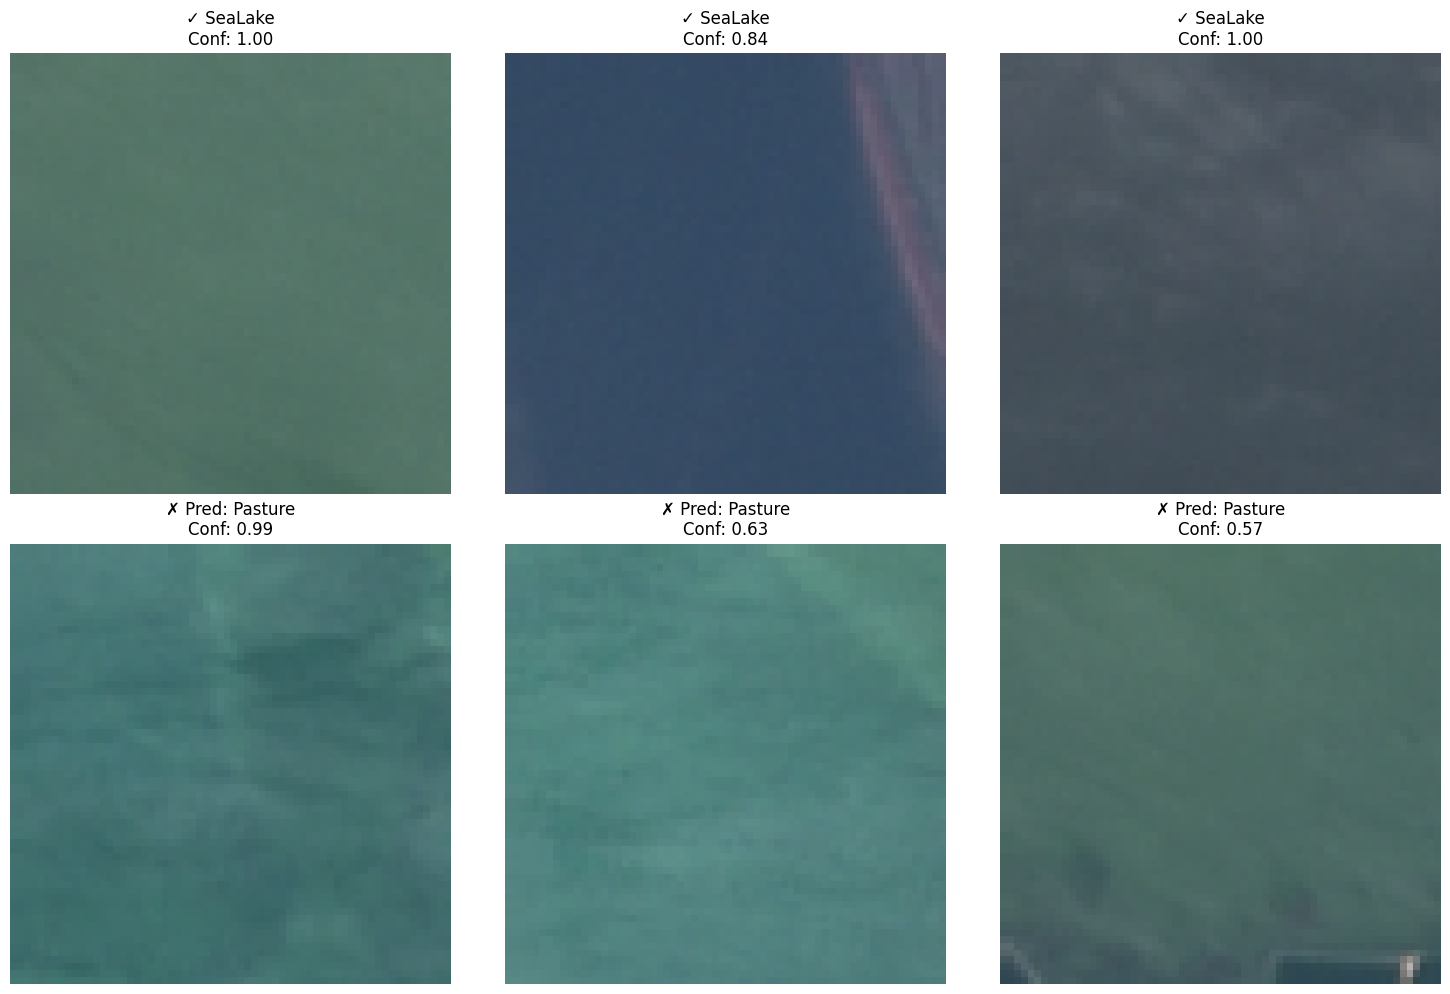

In [15]:
NUM_EXAMPLES = 3

for class_name in CLASS_NAMES:

    print("=" * 100)
    print(f"Class: {class_name}")
    print("=" * 100)

    correct_df = results_df[
        (results_df["true_class"] == class_name)
        &
        (results_df["correct"])
    ].sample(
        n=min(
            NUM_EXAMPLES,
            len(results_df[
                (results_df["true_class"] == class_name)
                &
                (results_df["correct"])
            ])
        ),
        random_state=42
    )

    incorrect_df = results_df[
        (results_df["true_class"] == class_name)
        &
        (~results_df["correct"])
    ].sample(
        n=min(
            NUM_EXAMPLES,
            len(results_df[
                (results_df["true_class"] == class_name)
                &
                (~results_df["correct"])
            ])
        ),
        random_state=42
    )

    fig, axes = plt.subplots(
        2,
        NUM_EXAMPLES,
        figsize=(5 * NUM_EXAMPLES, 10)
    )

    # -----------------------------
    # Correct Predictions
    # -----------------------------

    for i in range(NUM_EXAMPLES):

        ax = axes[0, i]

        if i < len(correct_df):

            row = correct_df.iloc[i]

            image = Image.open(
                row["filepath"]
            )

            ax.imshow(image)

            ax.set_title(
                f"✓ {row['predicted_class']}\n"
                f"Conf: {row['confidence']:.2f}"
            )

        ax.axis("off")

    # -----------------------------
    # Incorrect Predictions
    # -----------------------------

    for i in range(NUM_EXAMPLES):

        ax = axes[1, i]

        if i < len(incorrect_df):

            row = incorrect_df.iloc[i]

            image = Image.open(
                row["filepath"]
            )

            ax.imshow(image)

            ax.set_title(
                f"✗ Pred: {row['predicted_class']}\n"
                f"Conf: {row['confidence']:.2f}"
            )

        ax.axis("off")

    axes[0, 0].set_ylabel(
        "Correct",
        fontsize=14
    )

    axes[1, 0].set_ylabel(
        "Incorrect",
        fontsize=14
    )

    plt.tight_layout()

    plt.savefig(
        ERROR_ANALYSIS_DIR /
        f"{class_name}_examples.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [16]:
highest_confidence_errors = (

    results_df[
        ~results_df["correct"]
    ]

    .sort_values(
        "confidence",
        ascending=False
    )

    .reset_index(drop=True)

)

highest_confidence_errors.head(20)

,filepath,true_label,predicted_label,true_class,predicted_class,confidence,correct
0,c:\Users\ASUS\dev\projects\satellite-project-c...,6,2,PermanentCrop,HerbaceousVegetation,1.000000,False
1,c:\Users\ASUS\dev\projects\satellite-project-c...,6,2,PermanentCrop,HerbaceousVegetation,1.000000,False
2,c:\Users\ASUS\dev\projects\satellite-project-c...,6,2,PermanentCrop,HerbaceousVegetation,1.000000,False
3,c:\Users\ASUS\dev\projects\satellite-project-c...,6,2,PermanentCrop,HerbaceousVegetation,1.000000,False
4,c:\Users\ASUS\dev\projects\satellite-project-c...,6,2,PermanentCrop,HerbaceousVegetation,0.999999,False
5,c:\Users\ASUS\dev\projects\satellite-project-c...,6,2,PermanentCrop,HerbaceousVegetation,0.999999,False
6,c:\Users\ASUS\dev\projects\satellite-project-c...,6,2,PermanentCrop,HerbaceousVegetation,0.999998,False
7,c:\Users\ASUS\dev\projects\satellite-project-c...,6,2,PermanentCrop,HerbaceousVegetation,0.999998,False
8,c:\Users\ASUS\dev\projects\satellite-project-c...,6,2,PermanentCrop,HerbaceousVegetation,0.999997,False
9,c:\Users\ASUS\dev\projects\satellite-project-c...,3,6,Highway,PermanentCrop,0.999997,False


In [17]:
highest_confidence_errors.to_csv(

    ERROR_ANALYSIS_DIR /
    "highest_confidence_errors.csv",

    index=False

)

highest_confidence_errors.head(20)

,filepath,true_label,predicted_label,true_class,predicted_class,confidence,correct
0,c:\Users\ASUS\dev\projects\satellite-project-c...,6,2,PermanentCrop,HerbaceousVegetation,1.000000,False
1,c:\Users\ASUS\dev\projects\satellite-project-c...,6,2,PermanentCrop,HerbaceousVegetation,1.000000,False
2,c:\Users\ASUS\dev\projects\satellite-project-c...,6,2,PermanentCrop,HerbaceousVegetation,1.000000,False
3,c:\Users\ASUS\dev\projects\satellite-project-c...,6,2,PermanentCrop,HerbaceousVegetation,1.000000,False
4,c:\Users\ASUS\dev\projects\satellite-project-c...,6,2,PermanentCrop,HerbaceousVegetation,0.999999,False
5,c:\Users\ASUS\dev\projects\satellite-project-c...,6,2,PermanentCrop,HerbaceousVegetation,0.999999,False
6,c:\Users\ASUS\dev\projects\satellite-project-c...,6,2,PermanentCrop,HerbaceousVegetation,0.999998,False
7,c:\Users\ASUS\dev\projects\satellite-project-c...,6,2,PermanentCrop,HerbaceousVegetation,0.999998,False
8,c:\Users\ASUS\dev\projects\satellite-project-c...,6,2,PermanentCrop,HerbaceousVegetation,0.999997,False
9,c:\Users\ASUS\dev\projects\satellite-project-c...,3,6,Highway,PermanentCrop,0.999997,False


In [18]:
lowest_confidence_predictions = (

    results_df

    .sort_values(
        "confidence",
        ascending=True
    )

    .reset_index(drop=True)

)

lowest_confidence_predictions.head(20)

,filepath,true_label,predicted_label,true_class,predicted_class,confidence,correct
0,c:\Users\ASUS\dev\projects\satellite-project-c...,5,2,Pasture,HerbaceousVegetation,0.363260,False
1,c:\Users\ASUS\dev\projects\satellite-project-c...,3,4,Highway,Industrial,0.401703,False
2,c:\Users\ASUS\dev\projects\satellite-project-c...,8,3,River,Highway,0.407328,False
3,c:\Users\ASUS\dev\projects\satellite-project-c...,3,6,Highway,PermanentCrop,0.412517,False
4,c:\Users\ASUS\dev\projects\satellite-project-c...,2,2,HerbaceousVegetation,HerbaceousVegetation,0.417423,True
5,c:\Users\ASUS\dev\projects\satellite-project-c...,9,5,SeaLake,Pasture,0.419961,False
6,c:\Users\ASUS\dev\projects\satellite-project-c...,6,0,PermanentCrop,AnnualCrop,0.425724,False
7,c:\Users\ASUS\dev\projects\satellite-project-c...,0,6,AnnualCrop,PermanentCrop,0.432347,False
8,c:\Users\ASUS\dev\projects\satellite-project-c...,2,2,HerbaceousVegetation,HerbaceousVegetation,0.440575,True
9,c:\Users\ASUS\dev\projects\satellite-project-c...,0,5,AnnualCrop,Pasture,0.441047,False


In [19]:
lowest_confidence_predictions.to_csv(

    ERROR_ANALYSIS_DIR /
    "lowest_confidence_predictions.csv",

    index=False

)

lowest_confidence_predictions.head(20)

,filepath,true_label,predicted_label,true_class,predicted_class,confidence,correct
0,c:\Users\ASUS\dev\projects\satellite-project-c...,5,2,Pasture,HerbaceousVegetation,0.363260,False
1,c:\Users\ASUS\dev\projects\satellite-project-c...,3,4,Highway,Industrial,0.401703,False
2,c:\Users\ASUS\dev\projects\satellite-project-c...,8,3,River,Highway,0.407328,False
3,c:\Users\ASUS\dev\projects\satellite-project-c...,3,6,Highway,PermanentCrop,0.412517,False
4,c:\Users\ASUS\dev\projects\satellite-project-c...,2,2,HerbaceousVegetation,HerbaceousVegetation,0.417423,True
5,c:\Users\ASUS\dev\projects\satellite-project-c...,9,5,SeaLake,Pasture,0.419961,False
6,c:\Users\ASUS\dev\projects\satellite-project-c...,6,0,PermanentCrop,AnnualCrop,0.425724,False
7,c:\Users\ASUS\dev\projects\satellite-project-c...,0,6,AnnualCrop,PermanentCrop,0.432347,False
8,c:\Users\ASUS\dev\projects\satellite-project-c...,2,2,HerbaceousVegetation,HerbaceousVegetation,0.440575,True
9,c:\Users\ASUS\dev\projects\satellite-project-c...,0,5,AnnualCrop,Pasture,0.441047,False


In [20]:
report = classification_report(

    results_df["true_label"],

    results_df["predicted_label"],

    target_names=CLASS_NAMES,

    output_dict=True

)

classwise_df = (

    pd.DataFrame(report)

    .transpose()

    .iloc[:-3]

)

classwise_df = classwise_df[

    [

        "precision",

        "recall",

        "f1-score",

        "support"

    ]

]

classwise_df

,precision,recall,f1-score,support
AnnualCrop,0.873646,0.880000,0.876812,275.0
Forest,0.980952,0.980952,0.980952,105.0
HerbaceousVegetation,0.840268,0.885431,0.862259,707.0
Highway,0.967164,0.812030,0.882834,399.0
Industrial,0.859712,0.979508,0.915709,244.0
Pasture,0.466667,0.954545,0.626866,22.0
PermanentCrop,0.682713,0.670968,0.676790,465.0
Residential,0.976190,0.995951,0.985972,247.0
River,0.965116,0.775701,0.860104,107.0
SeaLake,0.948718,0.850575,0.896970,87.0


In [21]:
classwise_df.to_csv(

    ERROR_ANALYSIS_DIR /
    "classwise_metrics.csv"

)

classwise_df

,precision,recall,f1-score,support
AnnualCrop,0.873646,0.880000,0.876812,275.0
Forest,0.980952,0.980952,0.980952,105.0
HerbaceousVegetation,0.840268,0.885431,0.862259,707.0
Highway,0.967164,0.812030,0.882834,399.0
Industrial,0.859712,0.979508,0.915709,244.0
Pasture,0.466667,0.954545,0.626866,22.0
PermanentCrop,0.682713,0.670968,0.676790,465.0
Residential,0.976190,0.995951,0.985972,247.0
River,0.965116,0.775701,0.860104,107.0
SeaLake,0.948718,0.850575,0.896970,87.0


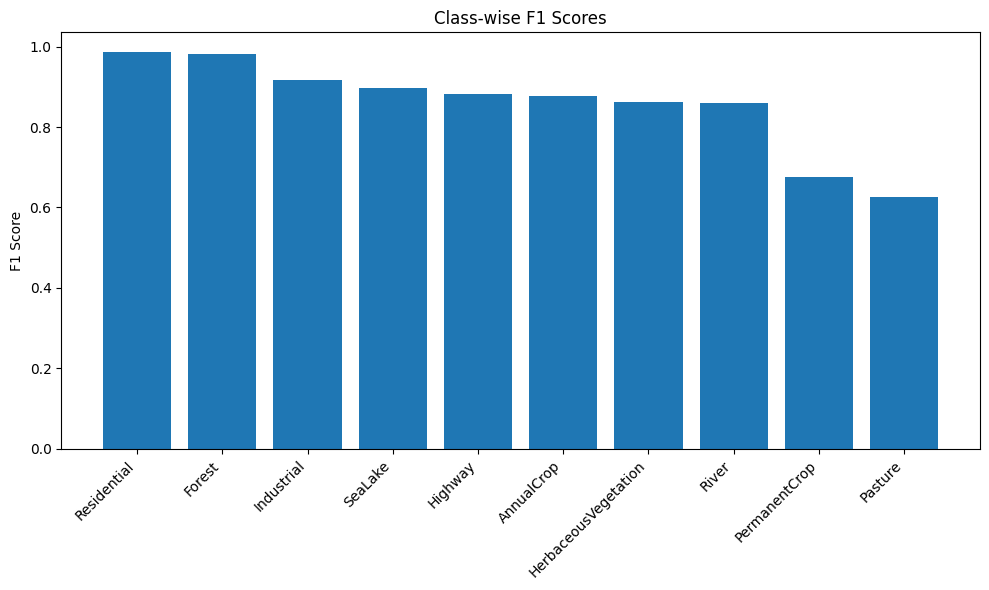

In [22]:
plot_df = classwise_df.sort_values(
    "f1-score",
    ascending=False
)

plt.figure(figsize=(10, 6))

plt.bar(

    plot_df.index,

    plot_df["f1-score"]

)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.ylabel("F1 Score")

plt.title("Class-wise F1 Scores")

plt.tight_layout()

plt.savefig(

    ERROR_ANALYSIS_DIR /
    "classwise_f1.png",

    dpi=300

)

plt.show()

In [23]:
summary = (

    classwise_df

    .sort_values(
        "f1-score",
        ascending=False
    )

    .round(3)

)

summary

,precision,recall,f1-score,support
Residential,0.976,0.996,0.986,247.0
Forest,0.981,0.981,0.981,105.0
Industrial,0.860,0.980,0.916,244.0
SeaLake,0.949,0.851,0.897,87.0
Highway,0.967,0.812,0.883,399.0
AnnualCrop,0.874,0.880,0.877,275.0
HerbaceousVegetation,0.840,0.885,0.862,707.0
River,0.965,0.776,0.860,107.0
PermanentCrop,0.683,0.671,0.677,465.0
Pasture,0.467,0.955,0.627,22.0


In [24]:
top_failures = (
    results_df[
        ~results_df["correct"]
    ]
    .sort_values(
        "confidence",
        ascending=False
    )
    .head(5)
    .reset_index(drop=True)
)

top_failures

,filepath,true_label,predicted_label,true_class,predicted_class,confidence,correct
0,c:\Users\ASUS\dev\projects\satellite-project\d...,6,2,PermanentCrop,HerbaceousVegetation,0.999993,False
1,c:\Users\ASUS\dev\projects\satellite-project\d...,3,6,Highway,PermanentCrop,0.999941,False
2,c:\Users\ASUS\dev\projects\satellite-project\d...,4,7,Industrial,Residential,0.999890,False
3,c:\Users\ASUS\dev\projects\satellite-project\d...,6,2,PermanentCrop,HerbaceousVegetation,0.999794,False
4,c:\Users\ASUS\dev\projects\satellite-project\d...,8,0,River,AnnualCrop,0.999766,False


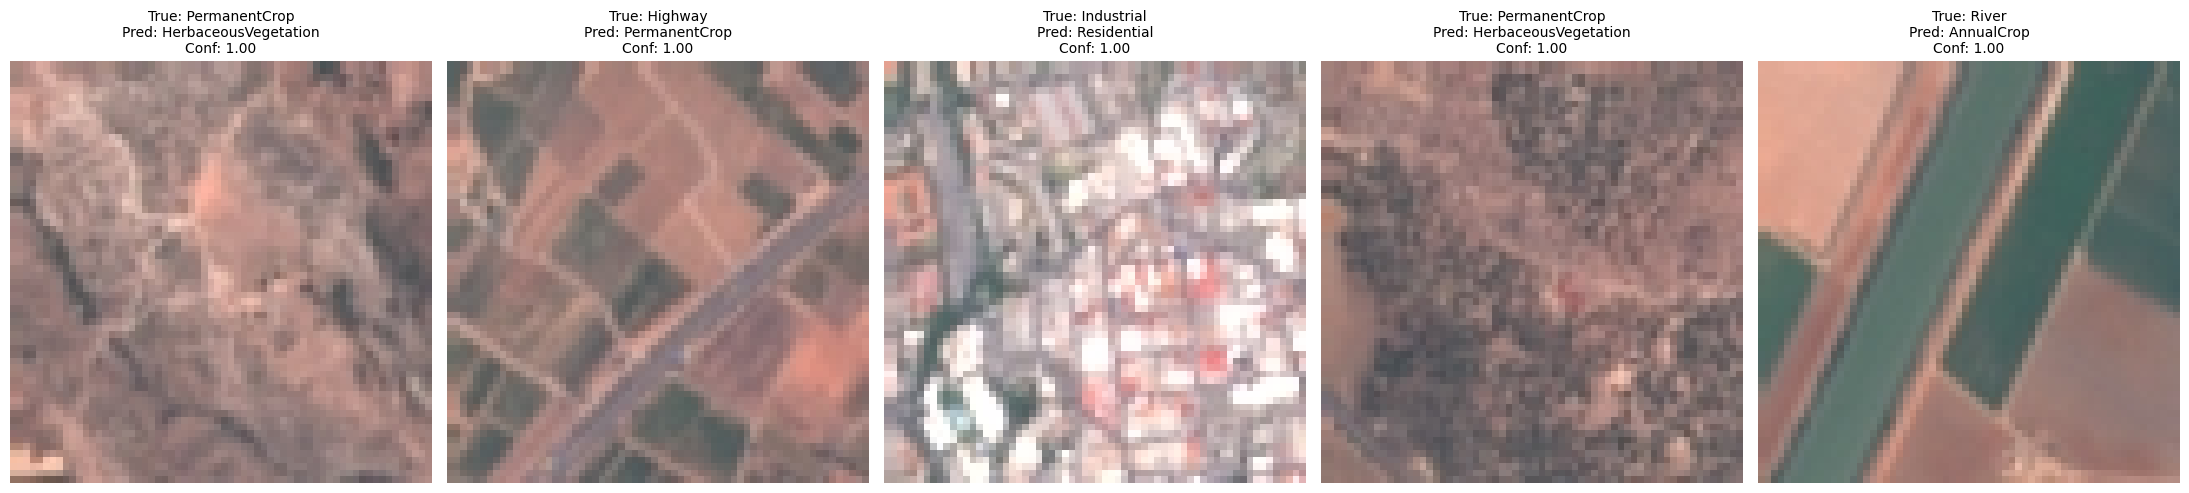

In [25]:
fig, axes = plt.subplots(
    1,
    5,
    figsize=(22,5)
)

for i, row in top_failures.iterrows():

    image = Image.open(row["filepath"]).convert("RGB")

    axes[i].imshow(image)
    axes[i].axis("off")

    axes[i].set_title(
        f"True: {row['true_class']}\n"
        f"Pred: {row['predicted_class']}\n"
        f"Conf: {row['confidence']:.2f}",
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    ERROR_ANALYSIS_DIR / "top5_failures.png",
    dpi=300
)

plt.show()

In [26]:
failure_summary = top_failures[
    [
        "true_class",
        "predicted_class",
        "confidence",
        "filepath"
    ]
].copy()

failure_summary["Hypothesis"] = ""

failure_summary

,true_class,predicted_class,confidence,filepath,Hypothesis
0,PermanentCrop,HerbaceousVegetation,0.999993,c:\Users\ASUS\dev\projects\satellite-project\d...,
1,Highway,PermanentCrop,0.999941,c:\Users\ASUS\dev\projects\satellite-project\d...,
2,Industrial,Residential,0.999890,c:\Users\ASUS\dev\projects\satellite-project\d...,
3,PermanentCrop,HerbaceousVegetation,0.999794,c:\Users\ASUS\dev\projects\satellite-project\d...,
4,River,AnnualCrop,0.999766,c:\Users\ASUS\dev\projects\satellite-project\d...,


In [27]:
failure_summary["Hypothesis"][0] = "The scene is dominated by dense vegetation with limited visible field boundaries. At the 64×64 resolution of EuroSAT, crop structure is difficult to distinguish from natural herbaceous vegetation, causing the model to rely primarily on texture rather than land-use context."
failure_summary["Hypothesis"][1] = "Only a relatively small portion of the image contains the highway, while the surrounding agricultural fields occupy most of the tile. The model appears to focus on the dominant land cover instead of the linear road feature, resulting in a prediction of PermanentCrop."
failure_summary["Hypothesis"][2] = "Industrial and residential areas both contain dense clusters of buildings, rooftops, and road networks. In this image, the absence of large industrial facilities or warehouses makes the visual appearance resemble a residential region."
failure_summary["Hypothesis"][3] = "Similar to the first example, vegetation texture dominates the image while crop patterns are not clearly visible. The limited spatial resolution reduces the distinction between cultivated vegetation and naturally occurring herbaceous cover."
failure_summary["Hypothesis"][4] = "The river occupies only a narrow portion of the tile, whereas agricultural fields cover most of the surrounding area. Consequently, the model assigns greater importance to the dominant farmland texture, leading to an incorrect AnnualCrop prediction."

In [28]:
failure_summary

,true_class,predicted_class,confidence,filepath,Hypothesis
0,PermanentCrop,HerbaceousVegetation,0.999993,c:\Users\ASUS\dev\projects\satellite-project\d...,The scene is dominated by dense vegetation wit...
1,Highway,PermanentCrop,0.999941,c:\Users\ASUS\dev\projects\satellite-project\d...,Only a relatively small portion of the image c...
2,Industrial,Residential,0.999890,c:\Users\ASUS\dev\projects\satellite-project\d...,Industrial and residential areas both contain ...
3,PermanentCrop,HerbaceousVegetation,0.999794,c:\Users\ASUS\dev\projects\satellite-project\d...,"Similar to the first example, vegetation textu..."
4,River,AnnualCrop,0.999766,c:\Users\ASUS\dev\projects\satellite-project\d...,The river occupies only a narrow portion of th...


In [29]:
for i in range(5):
    print(f"Hypothesis for error {i + 1}: {failure_summary['Hypothesis'][i]}")

Hypothesis for error 1: The scene is dominated by dense vegetation with limited visible field boundaries. At the 64×64 resolution of EuroSAT, crop structure is difficult to distinguish from natural herbaceous vegetation, causing the model to rely primarily on texture rather than land-use context.
Hypothesis for error 2: Only a relatively small portion of the image contains the highway, while the surrounding agricultural fields occupy most of the tile. The model appears to focus on the dominant land cover instead of the linear road feature, resulting in a prediction of PermanentCrop.
Hypothesis for error 3: Industrial and residential areas both contain dense clusters of buildings, rooftops, and road networks. In this image, the absence of large industrial facilities or warehouses makes the visual appearance resemble a residential region.
Hypothesis for error 4: Similar to the first example, vegetation texture dominates the image while crop patterns are not clearly visible. The limited s

# Findings and Conclusions

## Overall Performance

The fine-tuned ResNet18 model achieved strong performance on the spatially separated EuroSAT test set, demonstrating its ability to generalize to geographically distinct regions. Compared with the baseline CNN and the frozen ResNet18 model, fine-tuning consistently improved both overall accuracy and class-wise performance.

---

## Confidence Analysis

- Correct predictions generally exhibited higher confidence than incorrect predictions.
- Most misclassified samples had relatively lower confidence, indicating that the model was less certain when encountering ambiguous land-cover patterns.
- A small number of high-confidence errors remained, suggesting that some visually similar land-use classes are inherently difficult to distinguish.

---

## Confusion Analysis

The majority of classification errors occurred between visually similar classes, particularly among vegetation and agricultural categories.

Common confusions included:

- PermanentCrop ↔ AnnualCrop
- HerbaceousVegetation ↔ Pasture
- Highway ↔ Industrial

In contrast, highly distinctive classes such as Residential, Forest, and SeaLake achieved consistently high precision and recall.

---

## Visual Error Analysis

Inspection of correctly and incorrectly classified images showed that:

- Correct predictions generally contained clear and representative examples of each class.
- Incorrect predictions often contained mixed land-cover patterns, transitional regions, or ambiguous textures.
- Several errors could reasonably be interpreted as belonging to multiple classes due to the inherent similarity of satellite imagery.

---

## Class-wise Performance

The model achieved its highest F1 scores on classes with distinctive spatial patterns, such as:

- Residential
- Forest
- SeaLake

Lower F1 scores were observed for:

- PermanentCrop
- HerbaceousVegetation
- Pasture

These classes exhibit overlapping spectral and structural characteristics, making discrimination more challenging.

---

## Spatial Split Evaluation

The spatial train-validation-test split provided a substantially more realistic evaluation than a random split.

The random split produced noticeably higher performance because geographically nearby regions often contain highly similar imagery, allowing information leakage across dataset partitions. The spatial split prevents this leakage by ensuring geographic separation between training and evaluation data, resulting in a more reliable estimate of real-world generalization.

---

## External Generalization

Evaluation on the UC Merced Land Use dataset demonstrated that the model retained reasonable transferability despite differences in image distribution, scene composition, and dataset characteristics. As expected, performance decreased compared with EuroSAT due to domain shift, highlighting the importance of testing on external datasets.

---

## Temporal Change Detection

The feature embeddings extracted from the fine-tuned ResNet18 backbone were effective for temporal change detection. Using cosine similarity between paired embeddings, the detector achieved high discrimination between changed and unchanged image pairs.

The selected operating threshold provided a good balance between true positive and false positive rates, while the generated difference heatmaps offered intuitive visual explanations of detected changes.

---

## Final Conclusion

This project presents a complete remote sensing pipeline consisting of:

- Spatially aware dataset preparation
- Land-use classification using deep convolutional neural networks
- External validation on an unseen dataset
- Temporal change detection using learned feature embeddings
- Interactive deployment through a Streamlit application

The experiments demonstrate that incorporating spatially aware data partitioning leads to more realistic model evaluation and that learned deep feature representations can effectively support both land-use classification and change detection tasks.